# CDT Paper - Figure 2: Prediction Performance

**Version**: v3.3.1 (dropout 0.3)
**Date**: 2025-12-23

This notebook generates:
- **Figure 2A**: Prediction vs Actual scatter plot
- **Figure 2B**: Training curve (Loss and Pearson correlation)

Output: High-resolution figures for publication

## 1. Setup

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import pearsonr

# Paths
DRIVE_OUTPUT = Path("/content/drive/MyDrive/cdt_outputs/v3_3_1_dropout03")
FIGURE_OUTPUT = Path("/content/drive/MyDrive/cdt_outputs/paper_figures")
FIGURE_OUTPUT.mkdir(parents=True, exist_ok=True)

print(f"Output directory: {FIGURE_OUTPUT}")

Output directory: /content/drive/MyDrive/cdt_outputs/paper_figures


In [ ]:
# Check available files
!ls -lh /content/drive/MyDrive/cdt_outputs/v3_3_1_dropout03/

total 230M
-rw------- 1 root root 230M Dec 14 17:22 cdt_v3_3_1_dropout03_best.pt
-rw------- 1 root root 5.1K Dec 14 19:21 results_20251214_192119.json
-rw------- 1 root root 106K Dec 14 19:21 training_history.png


## 2. Load Training History

In [ ]:
# Find the results JSON file
result_files = list(DRIVE_OUTPUT.glob("results_*.json"))
print(f"Found {len(result_files)} result files")

# Load the most recent one
result_file = sorted(result_files)[-1]
print(f"Loading: {result_file}")

with open(result_file, 'r') as f:
    results = json.load(f)

print(f"\nVersion: {results['version']}")
print(f"Best Pearson: {results['best_pearson']:.4f}")
print(f"Final metrics: {results['final_metrics']}")

Found 1 result files
Loading: /content/drive/MyDrive/cdt_outputs/v3_3_1_dropout03/results_20251214_192119.json

Version: v3.3.1_dropout03
Best Pearson: 0.5032
Final metrics: {'r2': 0.10356754064559937, 'pearson_r': 0.5031848549842834, 'pearson_p': 4.832123808582717e-65, 'spearman_r': 0.4463325841755991, 'spearman_p': 6.30608884477244e-50, 'mse': 0.02000332437455654, 'mae': 0.08079317957162857}


In [ ]:
# Extract history
history = results['history']
epochs = range(1, len(history['train_loss']) + 1)

print(f"Training epochs: {len(epochs)}")
print(f"Best val Pearson: {max(history['val_pearson']):.4f} at epoch {np.argmax(history['val_pearson']) + 1}")

Training epochs: 26
Best val Pearson: 0.5032 at epoch 16


## 3. Generate Predictions for Scatter Plot

In [ ]:
# We need to run inference to get predictions
# First, define the model and dataset classes

import torch
import torch.nn as nn
from dataclasses import dataclass
from typing import Optional
import h5py

@dataclass
class CDTv33Config:
    dna_dim: int = 3072
    dna_seq_len: int = 896
    protein_dim: int = 768
    rna_dim: int = 512
    n_proteins: int = 2360
    hidden_dim: int = 768
    nhead: int = 8
    dropout: float = 0.3
    dna_self_attn_layers: int = 2
    rna_self_attn_layers: int = 1
    protein_self_attn_layers: int = 1


class SequenceProjector(nn.Module):
    def __init__(self, input_dim: int, output_dim: int, dropout: float = 0.1):
        super().__init__()
        self.linear = nn.Linear(input_dim, output_dim)
        self.norm = nn.LayerNorm(output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.dropout(self.norm(self.linear(x)))


class SelfAttentionBlock(nn.Module):
    def __init__(self, d_model: int, nhead: int = 4, dropout: float = 0.1):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * 4), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model), nn.Dropout(dropout)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, return_attention=False):
        attn_out, attn_weights = self.self_attn(x, x, x, need_weights=return_attention, average_attn_weights=False)
        x = self.norm1(x + self.dropout(attn_out))
        x = self.norm2(x + self.ffn(x))
        return x, attn_weights if return_attention else None


class CrossAttentionBlock(nn.Module):
    def __init__(self, d_model: int, nhead: int = 4, dropout: float = 0.1):
        super().__init__()
        self.cross_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * 4), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model), nn.Dropout(dropout)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, query, key_value):
        attn_out, attn_weights = self.cross_attn(query, key_value, key_value, need_weights=True, average_attn_weights=False)
        x = self.norm1(query + self.dropout(attn_out))
        x = self.norm2(x + self.ffn(x))
        return x, attn_weights


class VirtualCellEmbedderWithAttention(nn.Module):
    def __init__(self, d_model: int, dropout: float = 0.1):
        super().__init__()
        self.dna_query = nn.Parameter(torch.randn(1, 1, d_model))
        self.rna_query = nn.Parameter(torch.randn(1, 1, d_model))
        self.protein_query = nn.Parameter(torch.randn(1, 1, d_model))
        self.dna_attn = nn.MultiheadAttention(d_model, 4, dropout=dropout, batch_first=True)
        self.rna_attn = nn.MultiheadAttention(d_model, 4, dropout=dropout, batch_first=True)
        self.protein_attn = nn.MultiheadAttention(d_model, 4, dropout=dropout, batch_first=True)
        self.fusion = nn.Sequential(
            nn.Linear(d_model * 3, d_model * 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model), nn.LayerNorm(d_model)
        )

    def forward(self, dna, rna, protein):
        batch_size = dna.size(0)
        dna_pooled, _ = self.dna_attn(self.dna_query.expand(batch_size, -1, -1), dna, dna)
        rna_pooled, _ = self.rna_attn(self.rna_query.expand(batch_size, -1, -1), rna, rna)
        protein_pooled, _ = self.protein_attn(self.protein_query.expand(batch_size, -1, -1), protein, protein)
        concat = torch.cat([dna_pooled.squeeze(1), rna_pooled.squeeze(1), protein_pooled.squeeze(1)], dim=-1)
        return self.fusion(concat)


class CDTv33Model(nn.Module):
    def __init__(self, config: Optional[CDTv33Config] = None):
        super().__init__()
        if config is None:
            config = CDTv33Config()
        self.config = config

        self.dna_projector = SequenceProjector(config.dna_dim, config.hidden_dim, config.dropout)
        self.rna_projector = SequenceProjector(config.rna_dim, config.hidden_dim, config.dropout)
        self.protein_projector = SequenceProjector(config.protein_dim, config.hidden_dim, config.dropout)

        self.dna_self_attn_layers = nn.ModuleList([SelfAttentionBlock(config.hidden_dim, config.nhead, config.dropout) for _ in range(config.dna_self_attn_layers)])
        self.rna_self_attn_layers = nn.ModuleList([SelfAttentionBlock(config.hidden_dim, config.nhead, config.dropout) for _ in range(config.rna_self_attn_layers)])
        self.protein_self_attn_layers = nn.ModuleList([SelfAttentionBlock(config.hidden_dim, config.nhead, config.dropout) for _ in range(config.protein_self_attn_layers)])

        self.dna_to_rna = CrossAttentionBlock(config.hidden_dim, config.nhead, config.dropout)
        self.rna_to_protein = CrossAttentionBlock(config.hidden_dim, config.nhead, config.dropout)

        self.vce = VirtualCellEmbedderWithAttention(config.hidden_dim, config.dropout)
        self.task_layer = nn.Sequential(
            nn.Linear(config.hidden_dim, config.hidden_dim), nn.GELU(), nn.Dropout(config.dropout),
            nn.Linear(config.hidden_dim, config.n_proteins)
        )

    def forward(self, dna_emb, protein_emb, rna_emb, return_attention=False):
        batch_size = dna_emb.size(0)

        dna = self.dna_projector(dna_emb)
        rna = self.rna_projector(rna_emb)
        protein = self.protein_projector(protein_emb).unsqueeze(0).expand(batch_size, -1, -1)

        for layer in self.dna_self_attn_layers:
            dna, _ = layer(dna)
        for layer in self.rna_self_attn_layers:
            rna, _ = layer(rna)
        for layer in self.protein_self_attn_layers:
            protein, _ = layer(protein)

        rna, _ = self.dna_to_rna(query=rna, key_value=dna)
        protein, _ = self.rna_to_protein(query=protein, key_value=rna)

        cell_embedding = self.vce(dna, rna, protein)
        logits = self.task_layer(cell_embedding)

        return logits

print("Model classes defined.")

Model classes defined.


In [ ]:
# Copy data to local for faster access
import shutil

COLAB_DATA = Path("/content/colab_data_v3")
COLAB_DATA.mkdir(exist_ok=True)
TRAINING_DIR = COLAB_DATA / "training"
TRAINING_DIR.mkdir(exist_ok=True)

DRIVE_DATA = Path("/content/drive/MyDrive/cdt_data")

files_to_copy = [
    "human_proteomelm_embeddings_aligned.h5",
    "k562_gene_embeddings_aligned.h5",
    "protein_index_mapping_aligned.npz",
]

for f in files_to_copy:
    src = DRIVE_DATA / f
    dst = COLAB_DATA / f
    if src.exists() and not dst.exists():
        print(f"Copying {f}...")
        shutil.copy(src, dst)

# Copy validation data
val_src = DRIVE_DATA / "training" / "gasperini_val.h5"
val_dst = TRAINING_DIR / "gasperini_val.h5"
if val_src.exists() and not val_dst.exists():
    print("Copying gasperini_val.h5...")
    shutil.copy(val_src, val_dst)

print("Done!")

Copying human_proteomelm_embeddings_aligned.h5...
Copying k562_gene_embeddings_aligned.h5...
Copying protein_index_mapping_aligned.npz...
Copying gasperini_val.h5...
Done!


In [ ]:
# Load validation data and run inference
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# Simplified dataset for inference only
class ValidationDataset(Dataset):
    def __init__(self, val_path, dna_path, protein_path, rna_path, mapping_path):
        # Load index mapping
        data = np.load(mapping_path, allow_pickle=True)
        old_to_new_pairs = data['old_to_new']
        self.old_to_new_idx = {int(pair[0]): int(pair[1]) for pair in old_to_new_pairs}

        # Load validation data
        with h5py.File(val_path, 'r') as f:
            enformer_idx = f['enformer_idx'][:]
            orig_protein_idx = f['esm2_idx'][:]
            self.beta_values = f['beta'][:] if 'beta' in f else np.zeros_like(f['labels'][:], dtype=np.float32)
            self.enhancer_chr = [c.decode() if isinstance(c, bytes) else c for c in f['enhancer_chr'][:]]
            self.enhancer_start = f['enhancer_start'][:]
            self.enhancer_end = f['enhancer_end'][:]

        # Filter to aligned proteins
        valid_mask = np.array([int(idx) in self.old_to_new_idx for idx in orig_protein_idx])
        self.beta_values = self.beta_values[valid_mask]
        self.enhancer_chr = [c for c, v in zip(self.enhancer_chr, valid_mask) if v]
        self.enhancer_start = self.enhancer_start[valid_mask]
        self.enhancer_end = self.enhancer_end[valid_mask]
        valid_orig_idx = orig_protein_idx[valid_mask]
        self.protein_idx = np.array([self.old_to_new_idx[int(idx)] for idx in valid_orig_idx])

        # Load embeddings
        self.dna_file = h5py.File(dna_path, 'r')
        self.dna_emb = self.dna_file['embeddings']
        self.dna_centers = self.dna_file['centers'][:]
        self.dna_chroms = [c.decode() if isinstance(c, bytes) else c for c in self.dna_file['chroms'][:]]

        with h5py.File(protein_path, 'r') as f:
            self.protein_emb = f['embeddings'][:]

        with h5py.File(rna_path, 'r') as f:
            self.rna_emb = f['embeddings'][:]

        # Create coordinate mapping
        self._create_dna_mapping()

        print(f"Validation samples: {len(self.beta_values)}")

    def _create_dna_mapping(self):
        dna_coord_to_idx = {}
        for dna_idx, (chrom, center) in enumerate(zip(self.dna_chroms, self.dna_centers)):
            dna_coord_to_idx[(chrom, int(center))] = dna_idx

        self.sample_to_dna_idx = {}
        for sample_idx in range(len(self.enhancer_chr)):
            chrom = self.enhancer_chr[sample_idx]
            center = (self.enhancer_start[sample_idx] + self.enhancer_end[sample_idx]) // 2

            if (chrom, center) in dna_coord_to_idx:
                self.sample_to_dna_idx[sample_idx] = dna_coord_to_idx[(chrom, center)]
            else:
                # Try with tolerance
                found = False
                for dna_key, dna_idx in dna_coord_to_idx.items():
                    if dna_key[0] == chrom and abs(dna_key[1] - center) <= 1000:
                        self.sample_to_dna_idx[sample_idx] = dna_idx
                        found = True
                        break
                if not found:
                    self.sample_to_dna_idx[sample_idx] = None

    def __len__(self):
        return len(self.beta_values)

    def __getitem__(self, idx):
        dna_idx = self.sample_to_dna_idx.get(idx)
        if dna_idx is not None:
            dna_emb = self.dna_emb[dna_idx, :, :].astype(np.float32)
        else:
            dna_emb = np.zeros((896, 3072), dtype=np.float32)

        return {
            'dna_emb': torch.from_numpy(dna_emb),
            'rna_emb': torch.from_numpy(self.rna_emb.astype(np.float32)),
            'protein_idx': torch.tensor(int(self.protein_idx[idx]), dtype=torch.long),
            'beta': torch.tensor(self.beta_values[idx], dtype=torch.float32),
        }

    def get_protein_embeddings(self):
        return torch.from_numpy(self.protein_emb.astype(np.float32))

    def close(self):
        self.dna_file.close()

print("Dataset class defined.")

Dataset class defined.


In [ ]:
# Load dataset
val_dataset = ValidationDataset(
    val_path=TRAINING_DIR / "gasperini_val.h5",
    dna_path=Path("/content/drive/MyDrive/cdt_data/pilot_full_v2.h5"),
    protein_path=COLAB_DATA / "human_proteomelm_embeddings_aligned.h5",
    rna_path=COLAB_DATA / "k562_gene_embeddings_aligned.h5",
    mapping_path=COLAB_DATA / "protein_index_mapping_aligned.npz"
)

Validation samples: 996


In [ ]:
# Load model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = CDTv33Model(CDTv33Config()).to(device)
model.load_state_dict(torch.load(DRIVE_OUTPUT / "cdt_v3_3_1_dropout03_best.pt", map_location=device))
model.eval()

protein_emb = val_dataset.get_protein_embeddings().to(device)
print(f"Model loaded. Protein embeddings: {protein_emb.shape}")

Device: cuda
Model loaded. Protein embeddings: torch.Size([2360, 768])


In [ ]:
# Run inference
def collate_fn(batch):
    return {
        'dna_emb': torch.stack([item['dna_emb'] for item in batch]),
        'rna_emb': torch.stack([item['rna_emb'] for item in batch]),
        'protein_idx': torch.stack([item['protein_idx'] for item in batch]),
        'beta': torch.stack([item['beta'] for item in batch]),
    }

val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)

all_preds = []
all_targets = []

with torch.no_grad():
    for batch in tqdm(val_loader, desc="Inference"):
        dna = batch['dna_emb'].to(device)
        rna = batch['rna_emb'].to(device)
        protein_indices = batch['protein_idx'].to(device)
        betas = batch['beta']

        logits = model(dna, protein_emb, rna)
        pred = logits[range(len(protein_indices)), protein_indices]

        all_preds.extend(pred.cpu().numpy())
        all_targets.extend(betas.numpy())

predictions = np.array(all_preds)
targets = np.array(all_targets)

r, p = pearsonr(predictions, targets)
print(f"\nPearson r = {r:.4f} (p = {p:.2e})")
print(f"N samples = {len(predictions)}")

Inference: 100%|██████████| 125/125 [12:38<00:00,  6.06s/it]


Pearson r = 0.5032 (p = 4.83e-65)
N samples = 996


## 4. Create Figure 2A: Scatter Plot

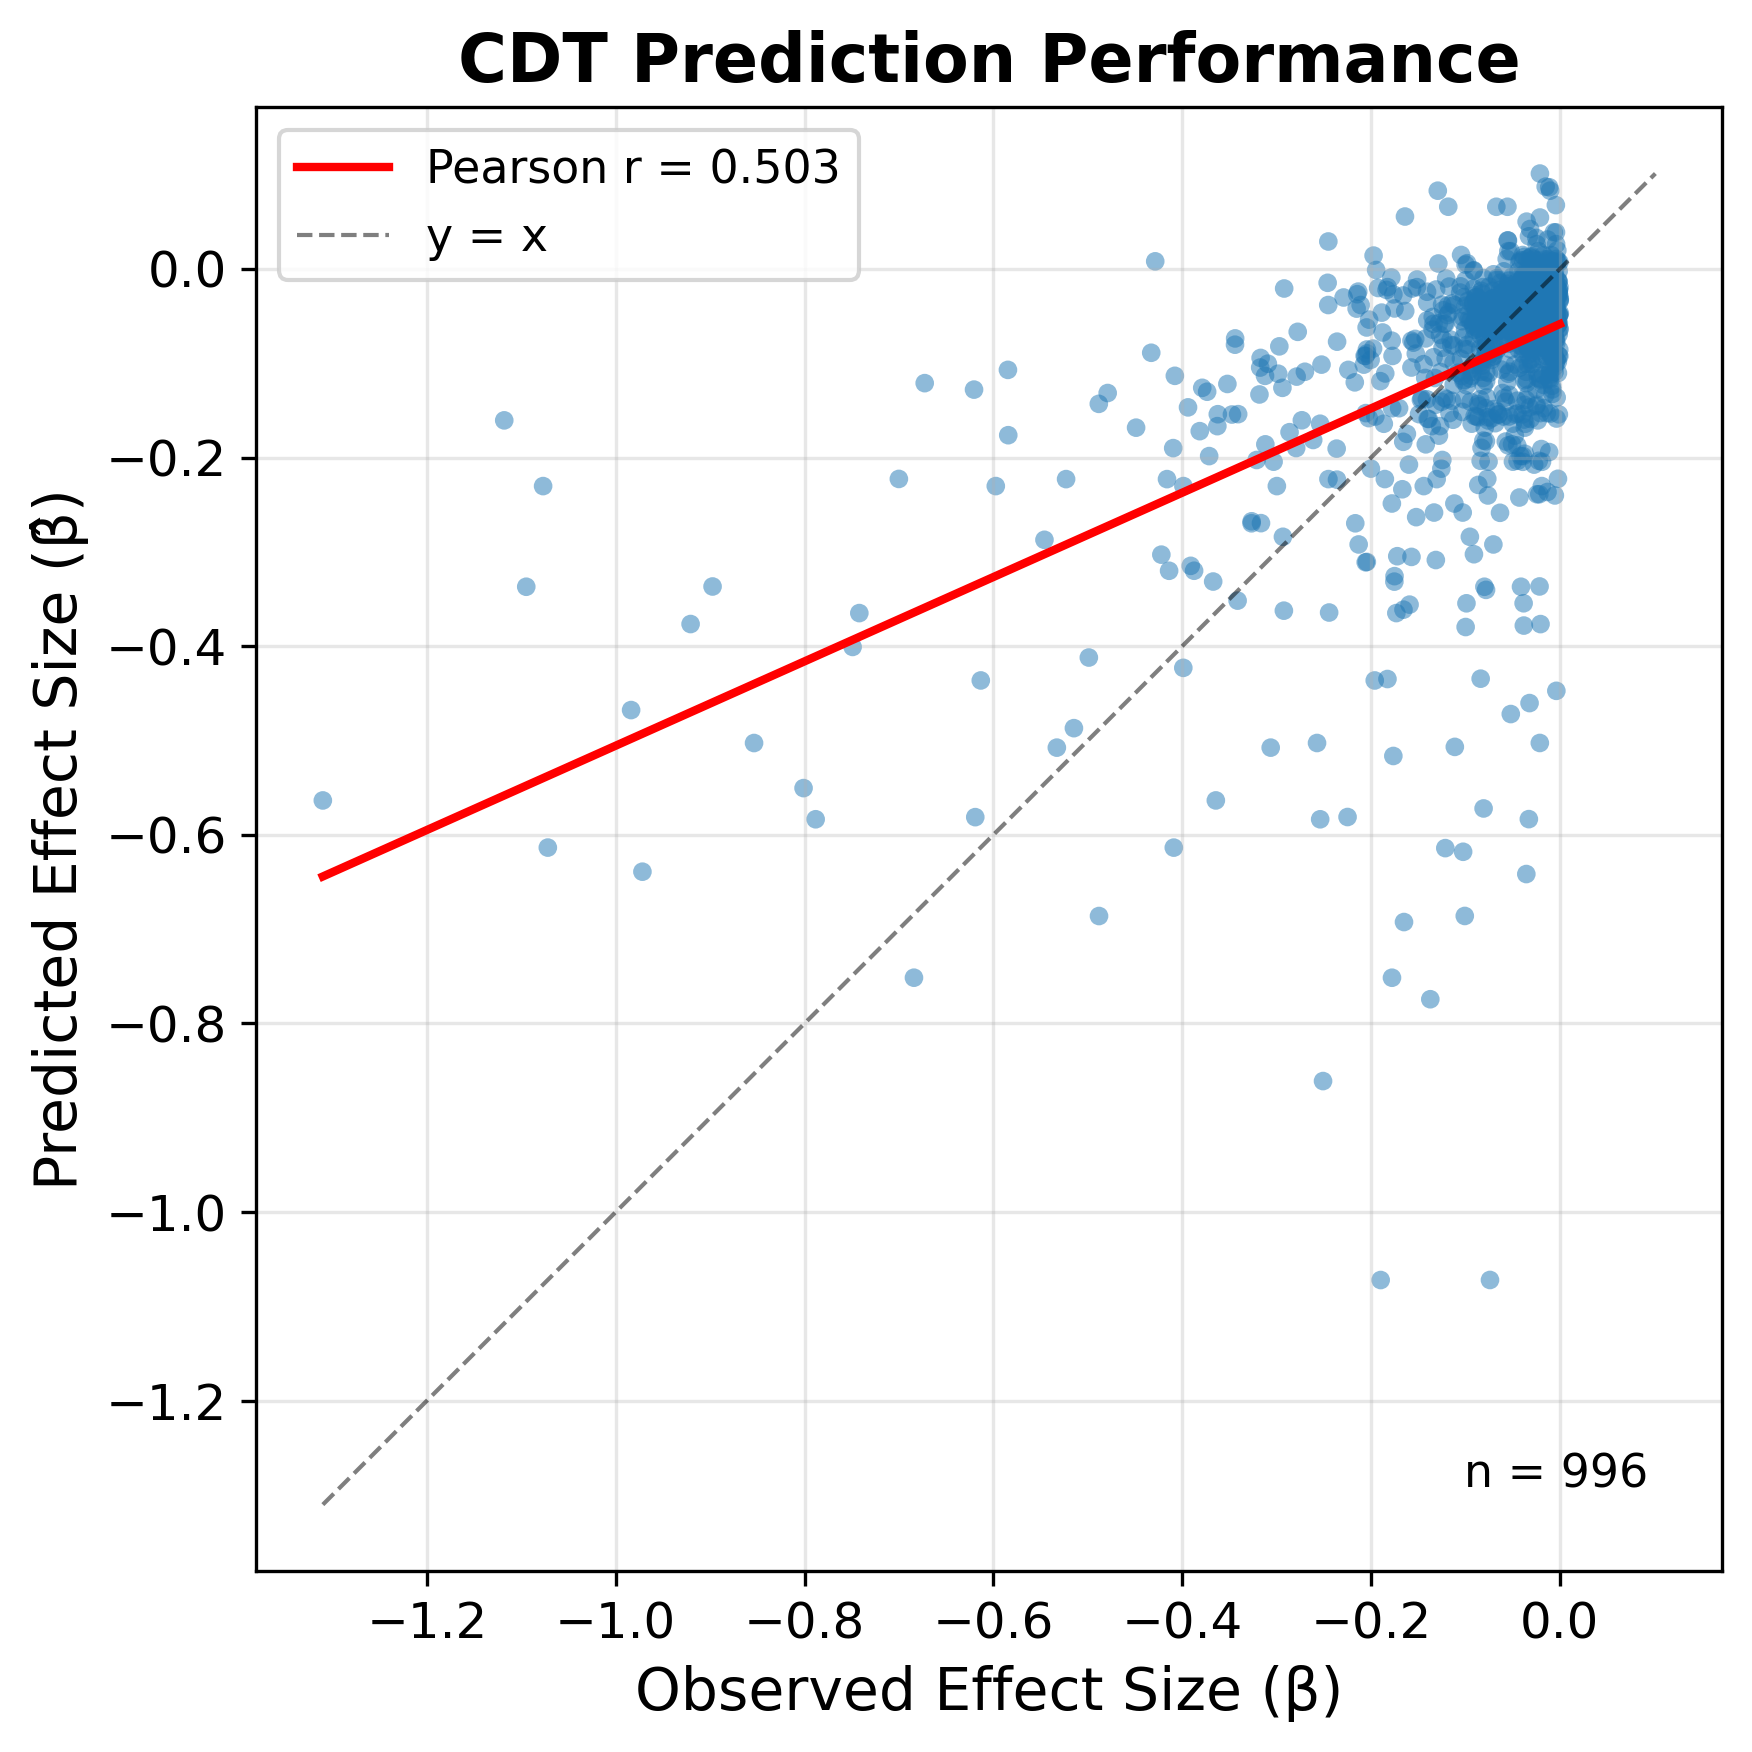

Saved to: /content/drive/MyDrive/cdt_outputs/paper_figures/figure2a_scatter.png


In [ ]:
# Publication-quality scatter plot
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 12

fig, ax = plt.subplots(figsize=(6, 6), dpi=300)

# Scatter plot
ax.scatter(targets, predictions, alpha=0.5, s=20, c='#1f77b4', edgecolors='none')

# Regression line
z = np.polyfit(targets, predictions, 1)
p_line = np.poly1d(z)
x_line = np.linspace(targets.min(), targets.max(), 100)
ax.plot(x_line, p_line(x_line), 'r-', linewidth=2, label=f'Pearson r = {r:.3f}')

# Identity line (dashed)
lims = [min(targets.min(), predictions.min()), max(targets.max(), predictions.max())]
ax.plot(lims, lims, 'k--', alpha=0.5, linewidth=1, label='y = x')

# Labels
ax.set_xlabel('Observed Effect Size (β)', fontsize=14)
ax.set_ylabel('Predicted Effect Size (β̂)', fontsize=14)
ax.set_title('CDT Prediction Performance', fontsize=16, fontweight='bold')

# Legend
ax.legend(loc='upper left', fontsize=11)

# Add sample count
ax.text(0.95, 0.05, f'n = {len(predictions)}', transform=ax.transAxes,
        ha='right', va='bottom', fontsize=11)

# Grid
ax.grid(True, alpha=0.3)

plt.tight_layout()

# Save
fig.savefig(FIGURE_OUTPUT / 'figure2a_scatter.png', dpi=300, bbox_inches='tight')
fig.savefig(FIGURE_OUTPUT / 'figure2a_scatter.pdf', bbox_inches='tight')
plt.show()

print(f"Saved to: {FIGURE_OUTPUT / 'figure2a_scatter.png'}")

## 5. Create Figure 2B: Training Curves

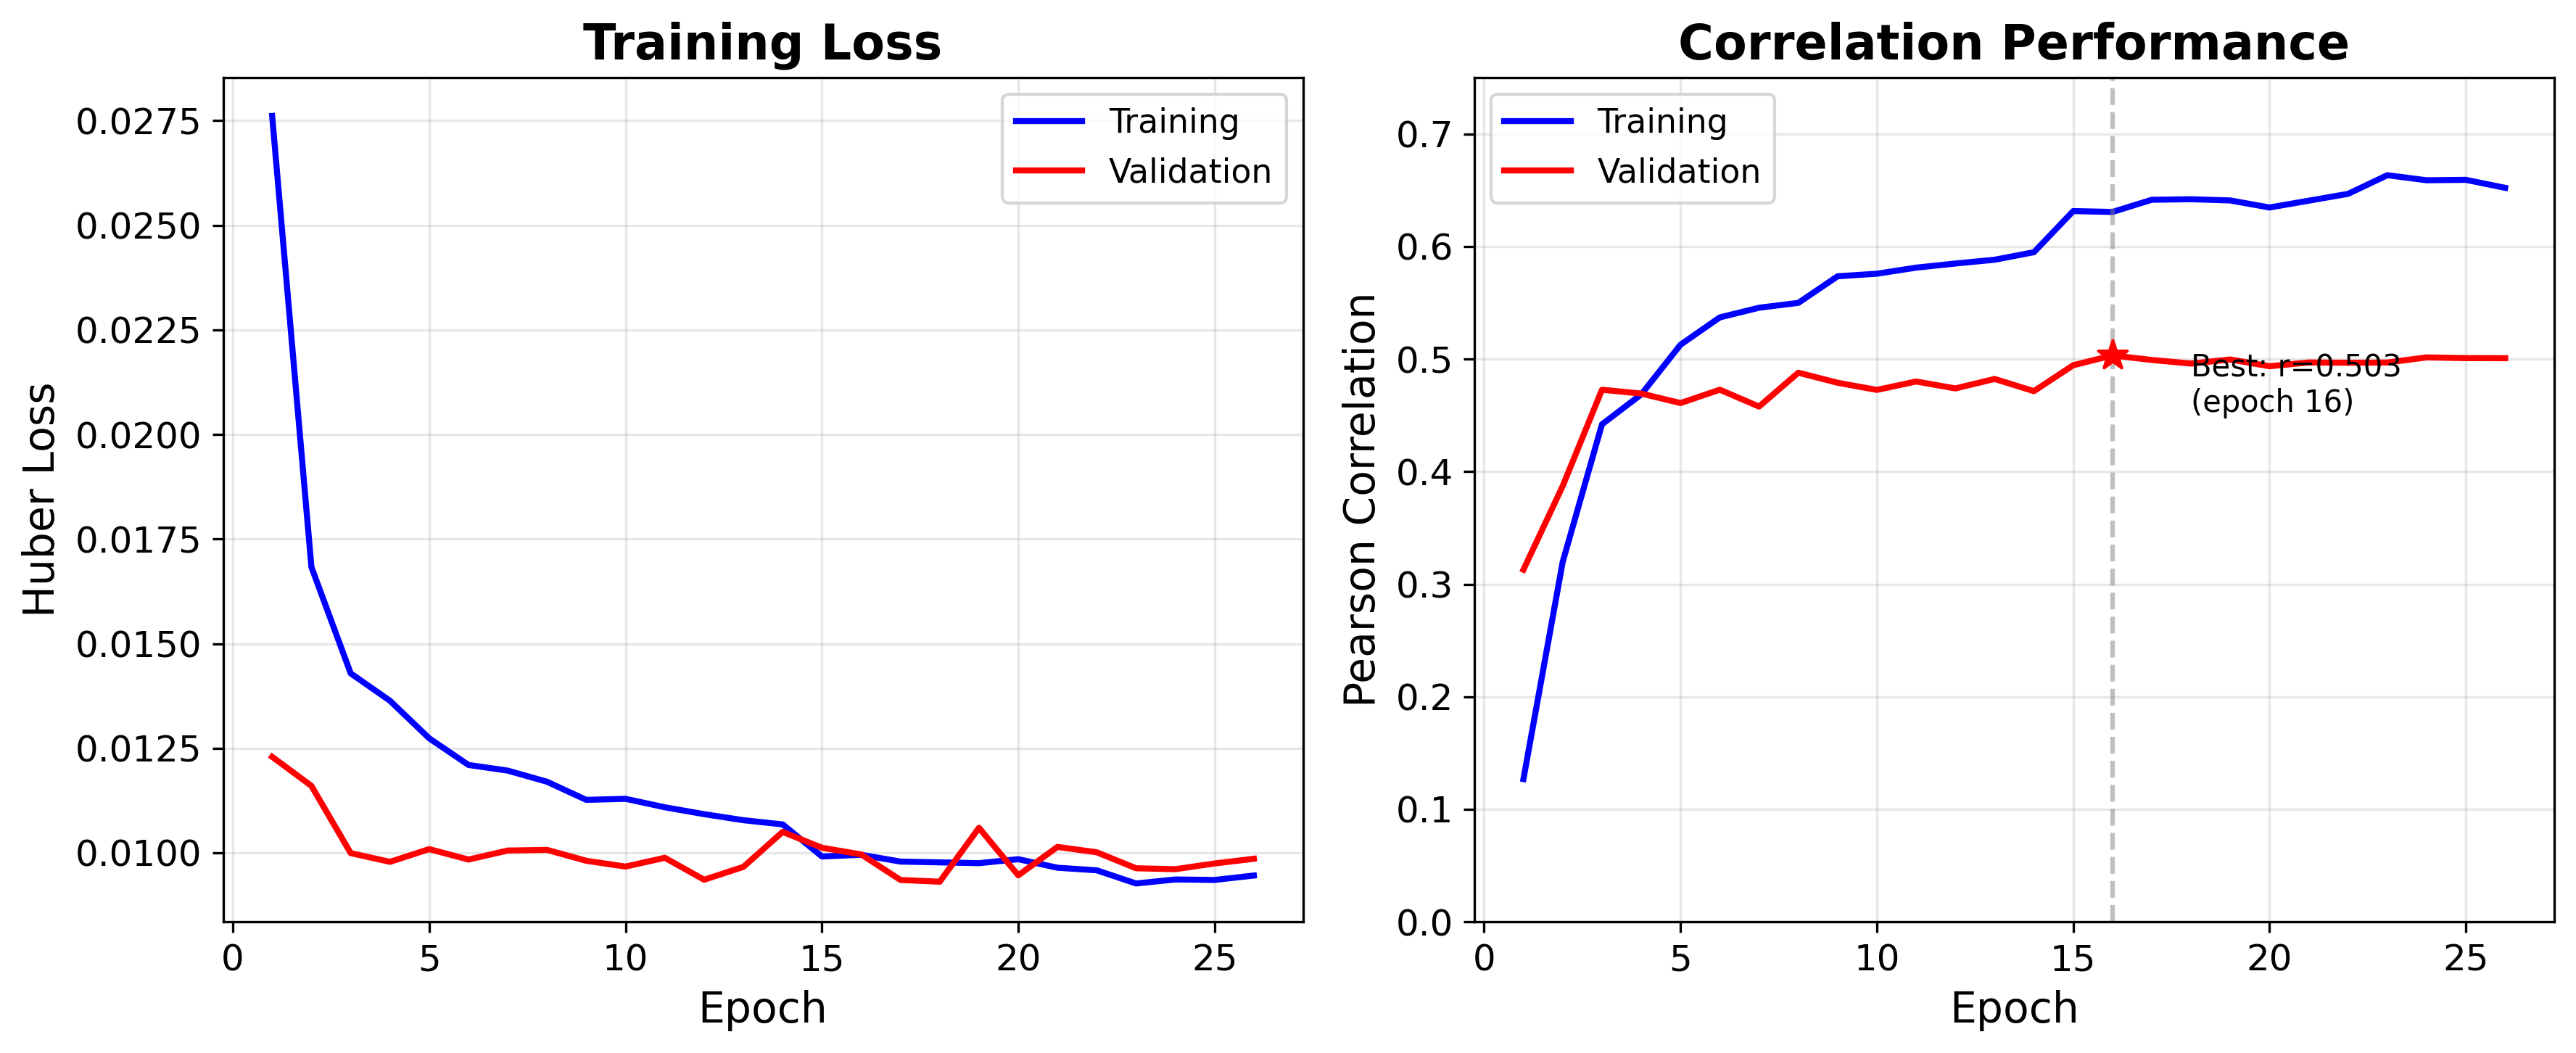

Saved to: /content/drive/MyDrive/cdt_outputs/paper_figures/figure2b_training_curves.png


In [ ]:
# Publication-quality training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=300)

epochs = range(1, len(history['train_loss']) + 1)

# Left: Loss
ax1 = axes[0]
ax1.plot(epochs, history['train_loss'], 'b-', linewidth=2, label='Training')
ax1.plot(epochs, history['val_loss'], 'r-', linewidth=2, label='Validation')
ax1.set_xlabel('Epoch', fontsize=14)
ax1.set_ylabel('Huber Loss', fontsize=14)
ax1.set_title('Training Loss', fontsize=16, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Right: Pearson correlation
ax2 = axes[1]
ax2.plot(epochs, history['train_pearson'], 'b-', linewidth=2, label='Training')
ax2.plot(epochs, history['val_pearson'], 'r-', linewidth=2, label='Validation')

# Mark best epoch
best_epoch = np.argmax(history['val_pearson']) + 1
best_val = max(history['val_pearson'])
ax2.axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.5)
ax2.scatter([best_epoch], [best_val], color='red', s=100, zorder=5, marker='*')
ax2.annotate(f'Best: r={best_val:.3f}\n(epoch {best_epoch})',
             xy=(best_epoch, best_val), xytext=(best_epoch + 2, best_val - 0.05),
             fontsize=10, ha='left')

ax2.set_xlabel('Epoch', fontsize=14)
ax2.set_ylabel('Pearson Correlation', fontsize=14)
ax2.set_title('Correlation Performance', fontsize=16, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 0.75)

plt.tight_layout()

# Save
fig.savefig(FIGURE_OUTPUT / 'figure2b_training_curves.png', dpi=300, bbox_inches='tight')
fig.savefig(FIGURE_OUTPUT / 'figure2b_training_curves.pdf', bbox_inches='tight')
plt.show()

print(f"Saved to: {FIGURE_OUTPUT / 'figure2b_training_curves.png'}")

## 6. Create Combined Figure 2

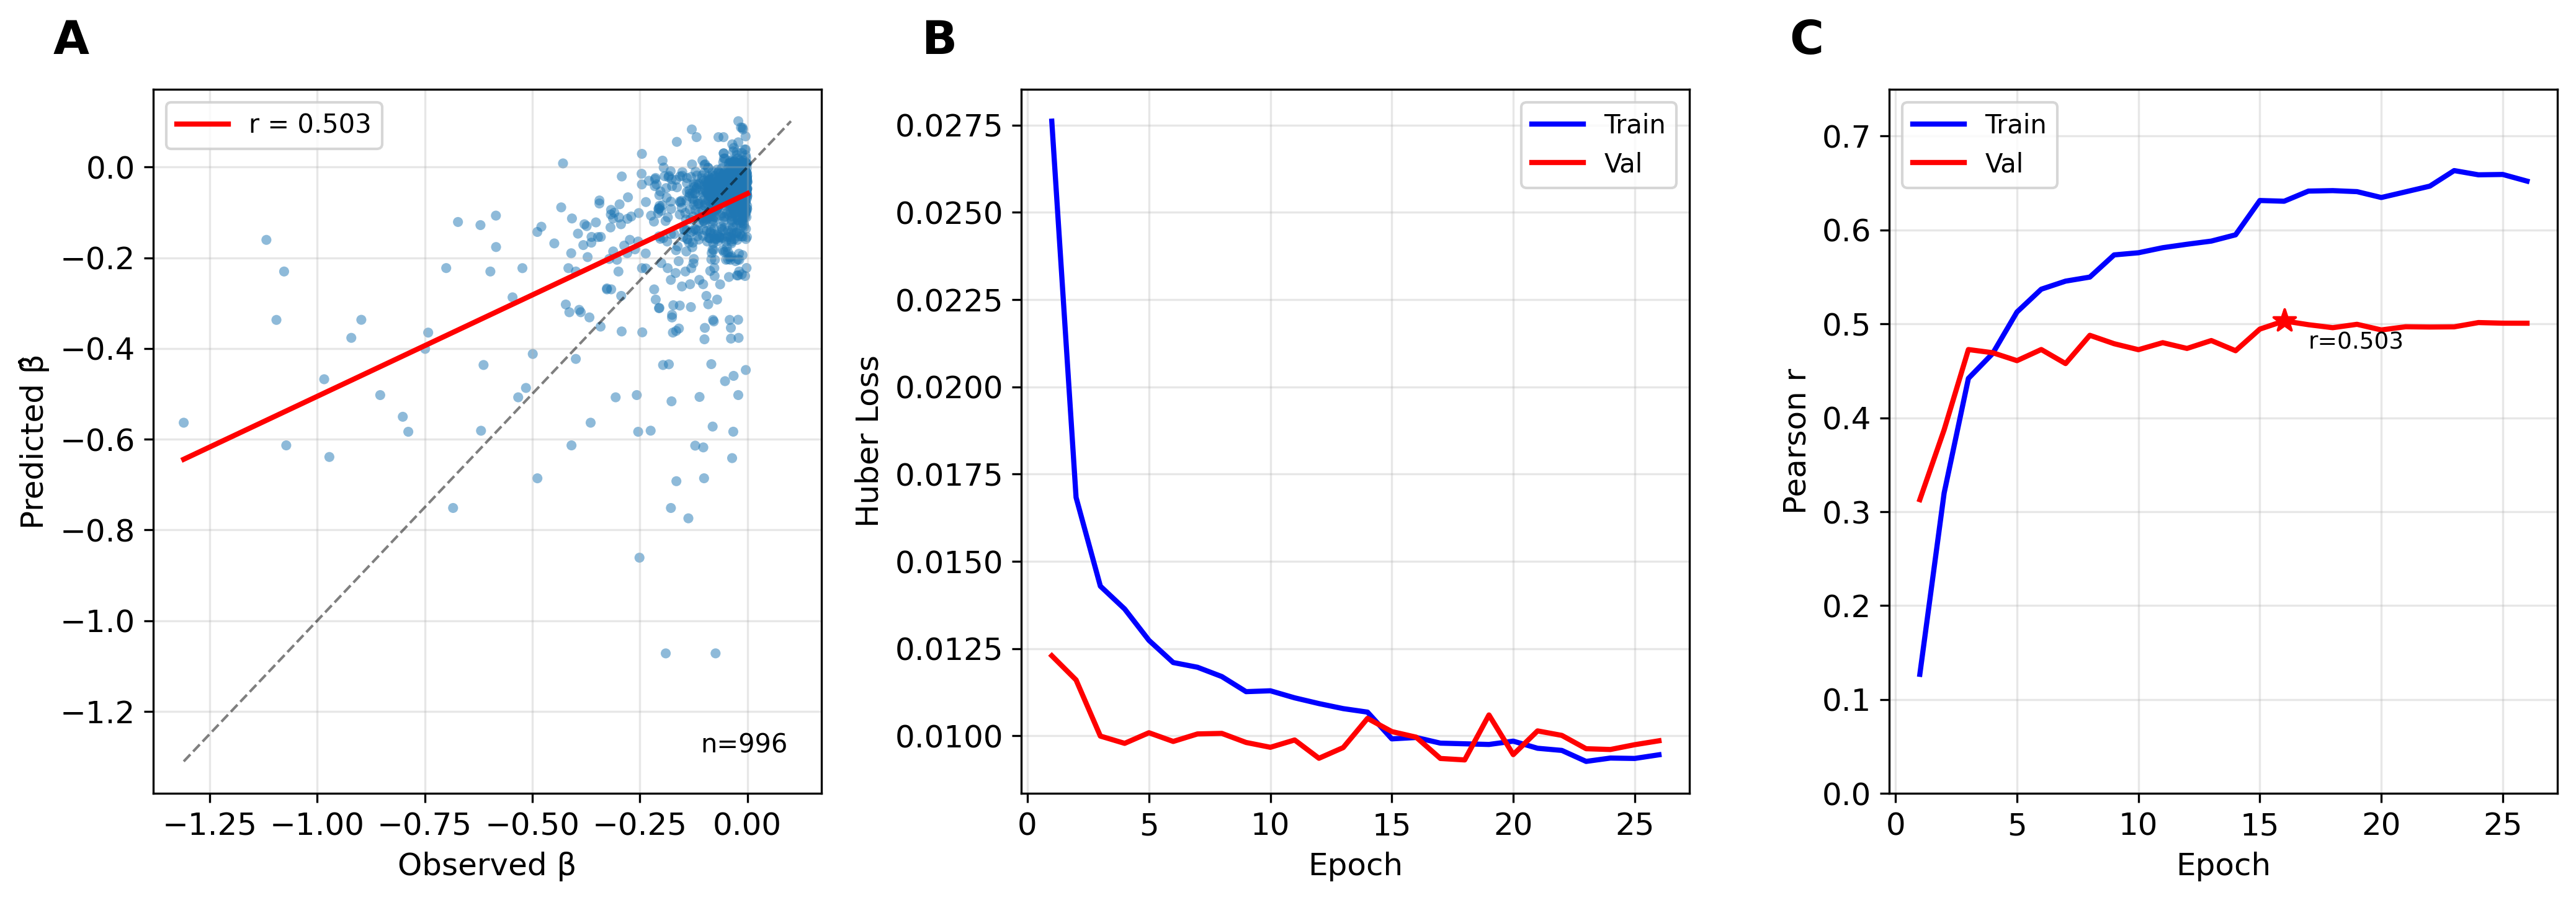


Saved to: /content/drive/MyDrive/cdt_outputs/paper_figures/figure2_combined.png


In [ ]:
# Combined figure with panel labels
fig = plt.figure(figsize=(14, 5), dpi=300)

# Panel A: Scatter plot
ax1 = fig.add_subplot(1, 3, 1)
ax1.scatter(targets, predictions, alpha=0.5, s=15, c='#1f77b4', edgecolors='none')
z = np.polyfit(targets, predictions, 1)
p_line = np.poly1d(z)
x_line = np.linspace(targets.min(), targets.max(), 100)
ax1.plot(x_line, p_line(x_line), 'r-', linewidth=2, label=f'r = {r:.3f}')
lims = [min(targets.min(), predictions.min()), max(targets.max(), predictions.max())]
ax1.plot(lims, lims, 'k--', alpha=0.5, linewidth=1)
ax1.set_xlabel('Observed β', fontsize=12)
ax1.set_ylabel('Predicted β̂', fontsize=12)
ax1.legend(loc='upper left', fontsize=10)
ax1.text(0.95, 0.05, f'n={len(predictions)}', transform=ax1.transAxes, ha='right', va='bottom', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.text(-0.15, 1.05, 'A', transform=ax1.transAxes, fontsize=18, fontweight='bold')

# Panel B: Loss
ax2 = fig.add_subplot(1, 3, 2)
ax2.plot(epochs, history['train_loss'], 'b-', linewidth=2, label='Train')
ax2.plot(epochs, history['val_loss'], 'r-', linewidth=2, label='Val')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Huber Loss', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.text(-0.15, 1.05, 'B', transform=ax2.transAxes, fontsize=18, fontweight='bold')

# Panel C: Pearson
ax3 = fig.add_subplot(1, 3, 3)
ax3.plot(epochs, history['train_pearson'], 'b-', linewidth=2, label='Train')
ax3.plot(epochs, history['val_pearson'], 'r-', linewidth=2, label='Val')
best_epoch = np.argmax(history['val_pearson']) + 1
best_val = max(history['val_pearson'])
ax3.scatter([best_epoch], [best_val], color='red', s=80, zorder=5, marker='*')
ax3.annotate(f'r={best_val:.3f}', xy=(best_epoch, best_val), xytext=(best_epoch + 1, best_val - 0.03), fontsize=9)
ax3.set_xlabel('Epoch', fontsize=12)
ax3.set_ylabel('Pearson r', fontsize=12)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.set_ylim(0, 0.75)
ax3.text(-0.15, 1.05, 'C', transform=ax3.transAxes, fontsize=18, fontweight='bold')

plt.tight_layout()

# Save
fig.savefig(FIGURE_OUTPUT / 'figure2_combined.png', dpi=300, bbox_inches='tight')
fig.savefig(FIGURE_OUTPUT / 'figure2_combined.pdf', bbox_inches='tight')
plt.show()

print(f"\nSaved to: {FIGURE_OUTPUT / 'figure2_combined.png'}")

In [ ]:
# Cleanup
val_dataset.close()

print("\n" + "="*60)
print("Figure 2 Generation Complete!")
print("="*60)
print(f"\nOutput files:")
print(f"  - {FIGURE_OUTPUT / 'figure2a_scatter.png'}")
print(f"  - {FIGURE_OUTPUT / 'figure2b_training_curves.png'}")
print(f"  - {FIGURE_OUTPUT / 'figure2_combined.png'}")
print(f"  - PDF versions also saved")


Figure 2 Generation Complete!

Output files:
  - /content/drive/MyDrive/cdt_outputs/paper_figures/figure2a_scatter.png
  - /content/drive/MyDrive/cdt_outputs/paper_figures/figure2b_training_curves.png
  - /content/drive/MyDrive/cdt_outputs/paper_figures/figure2_combined.png
  - PDF versions also saved
